In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# check out the data

In [86]:
!ls data/

current_foreground_noise_model.dat  foreground_noise_model.dat
current_instrument_noise_model.dat  full_noise_model.dat
current_sgwb_noise_model.dat        instrument_noise_model.dat
dft_data.dat                        power_data.dat
dwt_data.dat                        power_noise_reconstruction.dat
final_foreground_noise_model.dat    scaleogram_data.dat
final_full_noise_model.dat          sgwb_noise_model.dat
final_instrument_noise_model.dat    whitened_data.dat
final_sgwb_noise_model.dat


In [93]:
scaleogram_data = np.loadtxt('data/scaleogram_data.dat')
full_noise = np.loadtxt('data/full_noise_model.dat')
dwt_data = np.loadtxt('data/dwt_data.dat')

In [88]:
# cols are t, f, |X|^2, |Y|^2, |Z|^2

In [84]:
scaleogram_data.shape

(477900, 5)

In [85]:
# cols are t, f, CXX, CYY, CZZ, CXY, CXZ, CYZ

In [86]:
full_noise.shape[0]//4050

118

In [87]:
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from matplotlib import colors
%matplotlib inline
# TODO: separate real/imag FFT coeffs in each layer
def wavelet_specgram(t, f, pz, Nt = 512, clip = 0, lognorm=False, cmap='bwr', cx_norm='abs'):
    Nf = t.shape[0] // Nt
    if t.shape[0] != Nt*Nf or f.shape[0] != Nt*Nf:
        print("Nt or Nf is wrong")
    z = pz.copy()
    if lognorm:
        z = np.ma.masked_less_equal(z.astype(float), 0)
        lo, hi = np.nanpercentile(z.compressed(), [clip, 100-clip])
        norm = colors.AsinhNorm(vmin=lo, vmax = hi, clip=True)
    else:
        lo, hi = np.nanpercentile(z, [clip, 100-clip])
        norm = colors.Normalize(vmin=lo, vmax = hi, clip=True)
    #plt.imshow(z.reshape((Nf,Nt)),cmap=cmap,norm=norm,aspect=9/16*Nt/Nf,interpolation='none')
    fig, ax = plt.subplots()
    m = ax.pcolormesh(t[::Nf], f[:Nf], z.reshape((Nt,Nf)).T, cmap=cmap, norm=norm, shading='auto',snap=True, rasterized=True)
    fig.colorbar(m,ax=ax)
    plt.xlabel('t')
    plt.ylabel('f')
    plt.show()
    

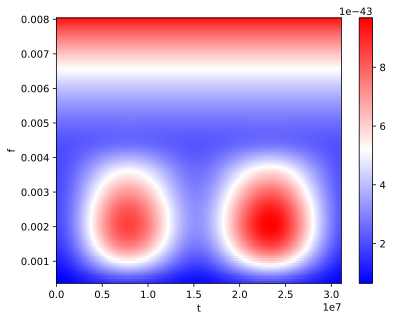

In [93]:
wavelet_specgram(full_noise[:,0], full_noise[:,1], full_noise[:,2], Nt=4050)

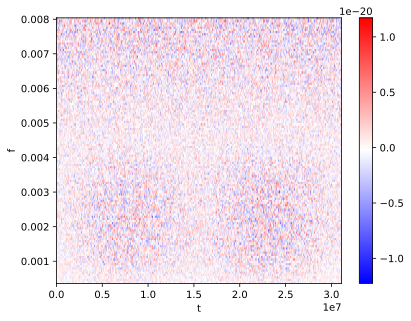

In [38]:
wavelet_specgram(dwt_data[:,0], dwt_data[:,1], dwt_data[:,2], Nt=4050)

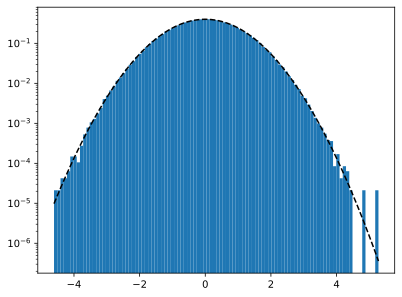

In [94]:
# gaussianity test of generated data
# fudge_factor = 3 # implemented in code
counts,bins,_ = plt.hist(dwt_data[:,4] / np.sqrt(full_noise[:,4]), density=True, bins=100)
x = np.linspace(bins[0],bins[-1],100)
plt.plot(x, np.exp(-x**2 / 2) * np.max(counts), color='k', linestyle = '--')
plt.yscale('log')

In [89]:
  whitened = dwt_data[:,4] / np.sqrt(full_noise[:,4])
  print(f"Whitened variance: {np.var(whitened):.4f}")
  print(f"Expected if correct: 1.0")
  print(f"Expected with fudge factor issue: {1/9:.4f} = 0.1111")

Whitened variance: 1.0004
Expected if correct: 1.0
Expected with fudge factor issue: 0.1111 = 0.1111


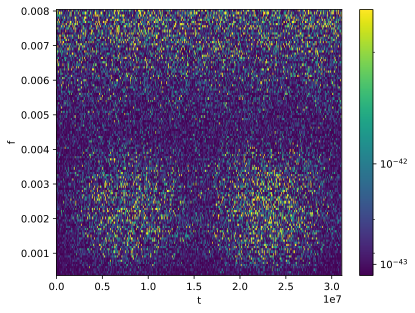

In [100]:
wavelet_specgram(scaleogram_data[:,0], scaleogram_data[:,1], scaleogram_data[:,2], Nt=4050, clip=3, lognorm=True, cmap='viridis')

In [433]:
np.std(scaleogram_data[:,2] / full_noise[:,2])

np.float64(1.4183200867726555)

# check out the chains

In [2]:
sgwb = np.loadtxt('chains-bug/sgwb_chain.dat')#, max_rows=900)

In [130]:
sgwb = np.loadtxt('chains-sgwb-only/sgwb_chain.dat')

In [310]:
N = 3000
sgwb = np.loadtxt('chains/sgwb_chain.dat', max_rows=N)
inst = np.loadtxt('chains/noise_chain.dat', max_rows=N)
galx = np.loadtxt('chains/foreground_chain.dat', max_rows=N)

In [311]:
sgwb.shape

(3000, 4)

In [312]:
inst.shape

(3000, 14)

In [313]:
galx.shape

(3000, 7)

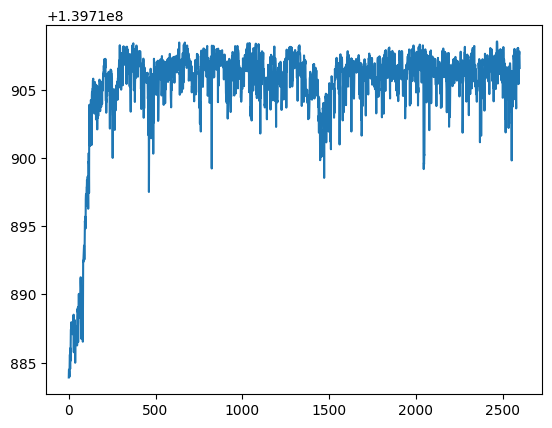

In [314]:
plt.plot(inst[400:,1])

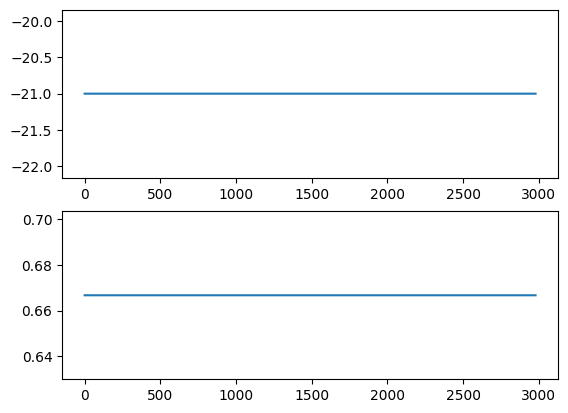

In [315]:
# sgwb trace

fig, ax = plt.subplots(2,1)
ax[0].plot(sgwb[20:,2])
ax[1].plot(sgwb[20:,3])

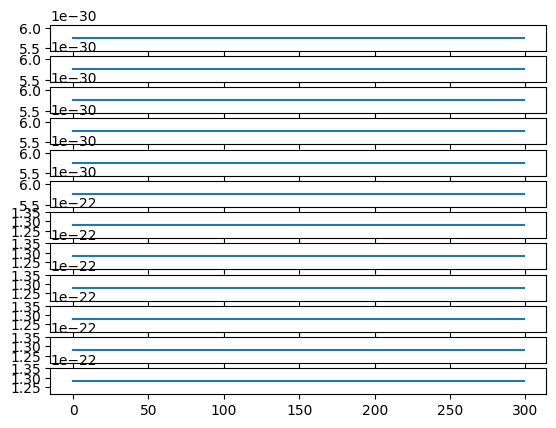

In [301]:
# inst trace
burn = 0
fig, ax = plt.subplots(12,1)
for i in range(12):
    ax[i].plot(inst[burn:,i+2])

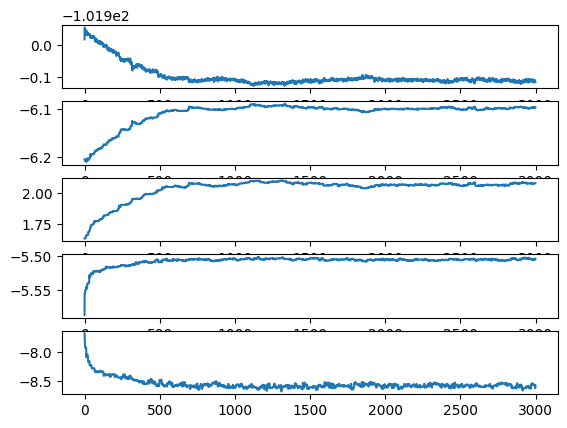

In [316]:
burn = 0
fig, ax = plt.subplots(5,1)
for i in range(5):
    ax[i].plot(galx[burn:,i+2])

In [303]:
from corner import corner

In [319]:
burn = 1000
sgwb_chain = np.array(
    [
        sgwb[burn:,2], # logA
        sgwb[burn:,3], # alpha
    ]).T
sgwb_labels = [r'$\log A_p$', r'$\alpha$']

In [320]:
inst_chain = np.array(
    [
        inst[burn:,i+2]
        for i in range(12)
    ]).T
inst_labels = [r'$\log S_{\mathrm{acc},12}$',
r'$\log S_{\mathrm{acc},21}$',
r'$\log S_{\mathrm{acc},13}$',
r'$\log S_{\mathrm{acc},31}$',
r'$\log S_{\mathrm{acc},23}$', 
r'$\log S_{\mathrm{acc},32}$', 
r'$\log S_{\mathrm{oms},12}$', 
r'$\log S_{\mathrm{oms},21}$', 
r'$\log S_{\mathrm{oms},13}$', 
r'$\log S_{\mathrm{oms},31}$', 
r'$\log S_{\mathrm{oms},23}$', 
r'$\log S_{\mathrm{oms},32}$']

In [321]:
galx_chain = np.array(
    [
        galx[burn:,i+2]
        for i in range(5)
    ]).T
galx_labels = [r'$\log A$', r'$f_1$', r'$\alpha$', r'$f_k$', r'$f_2$']

ValueError: It looks like the parameter(s) in column(s) 0, 1 have no dynamic range. Please provide a `range` argument.

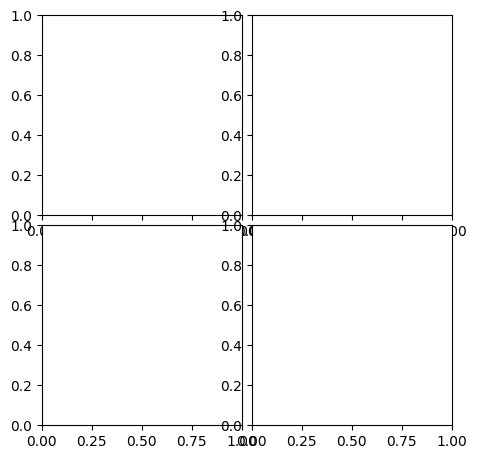

In [322]:
corner(sgwb_chain, labels = sgwb_labels)
plt.show()

ValueError: It looks like the parameter(s) in column(s) 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11 have no dynamic range. Please provide a `range` argument.

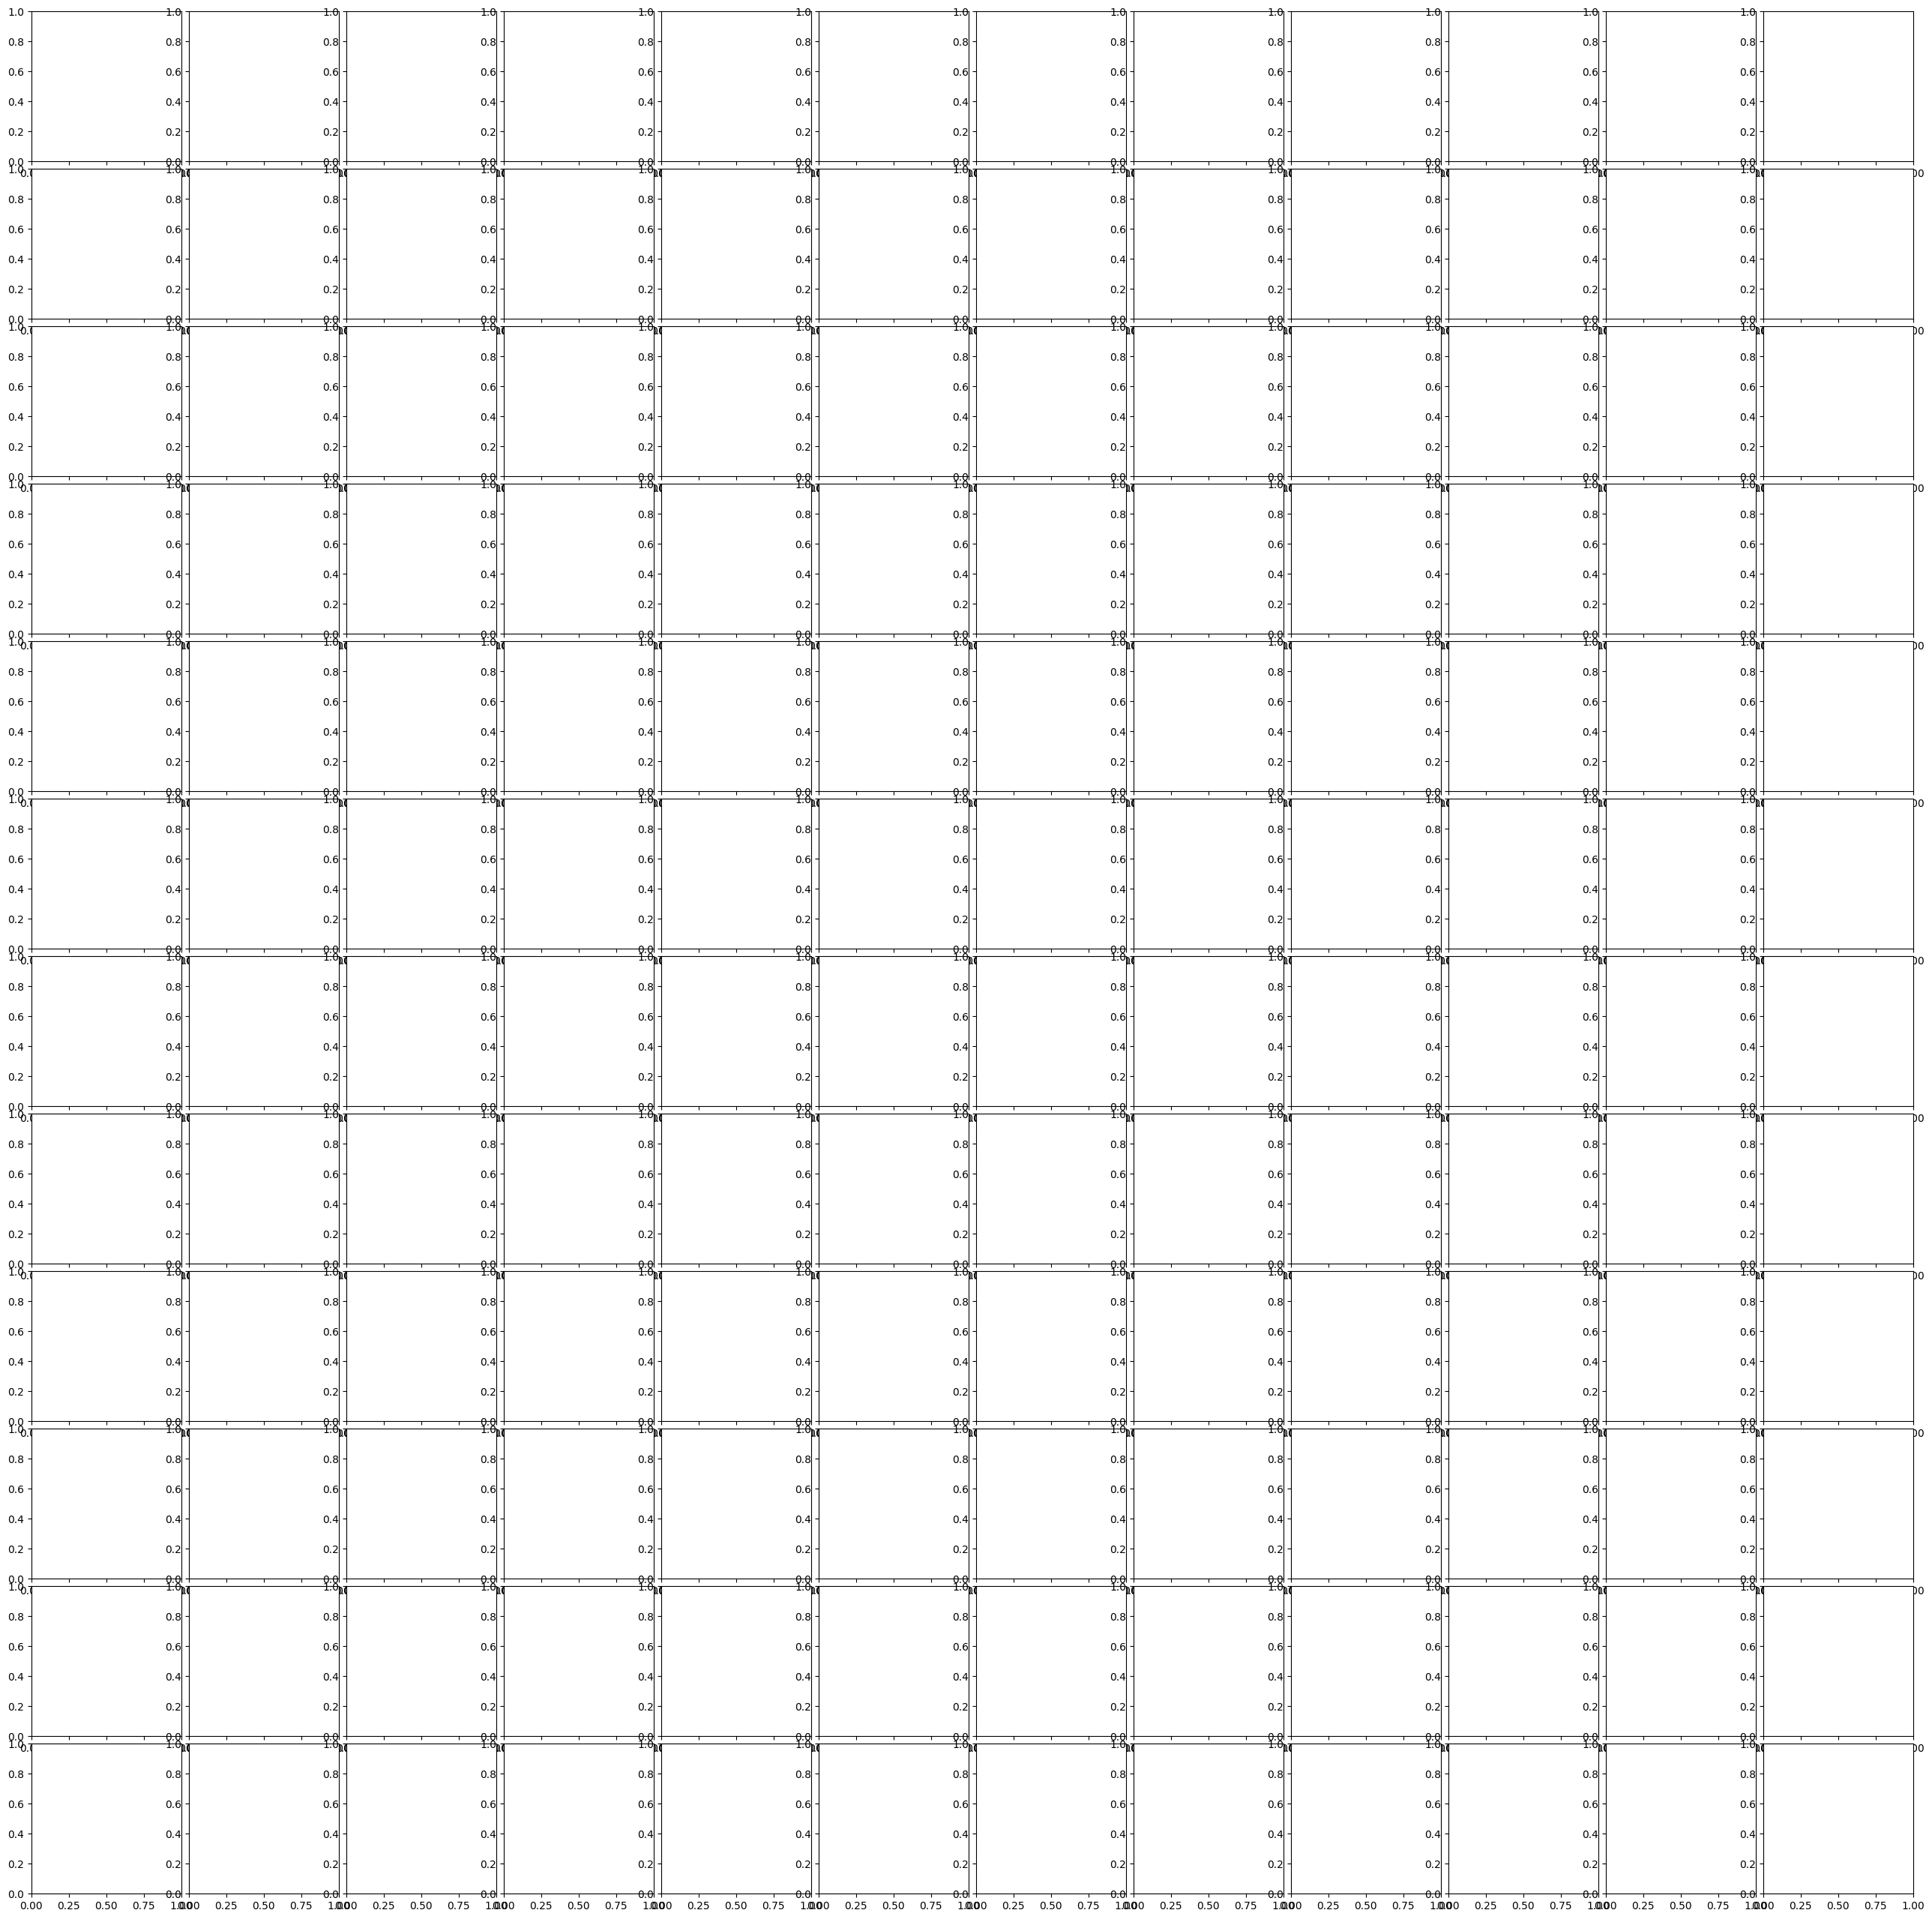

In [323]:
corner(inst_chain, labels = inst_labels)
plt.show()

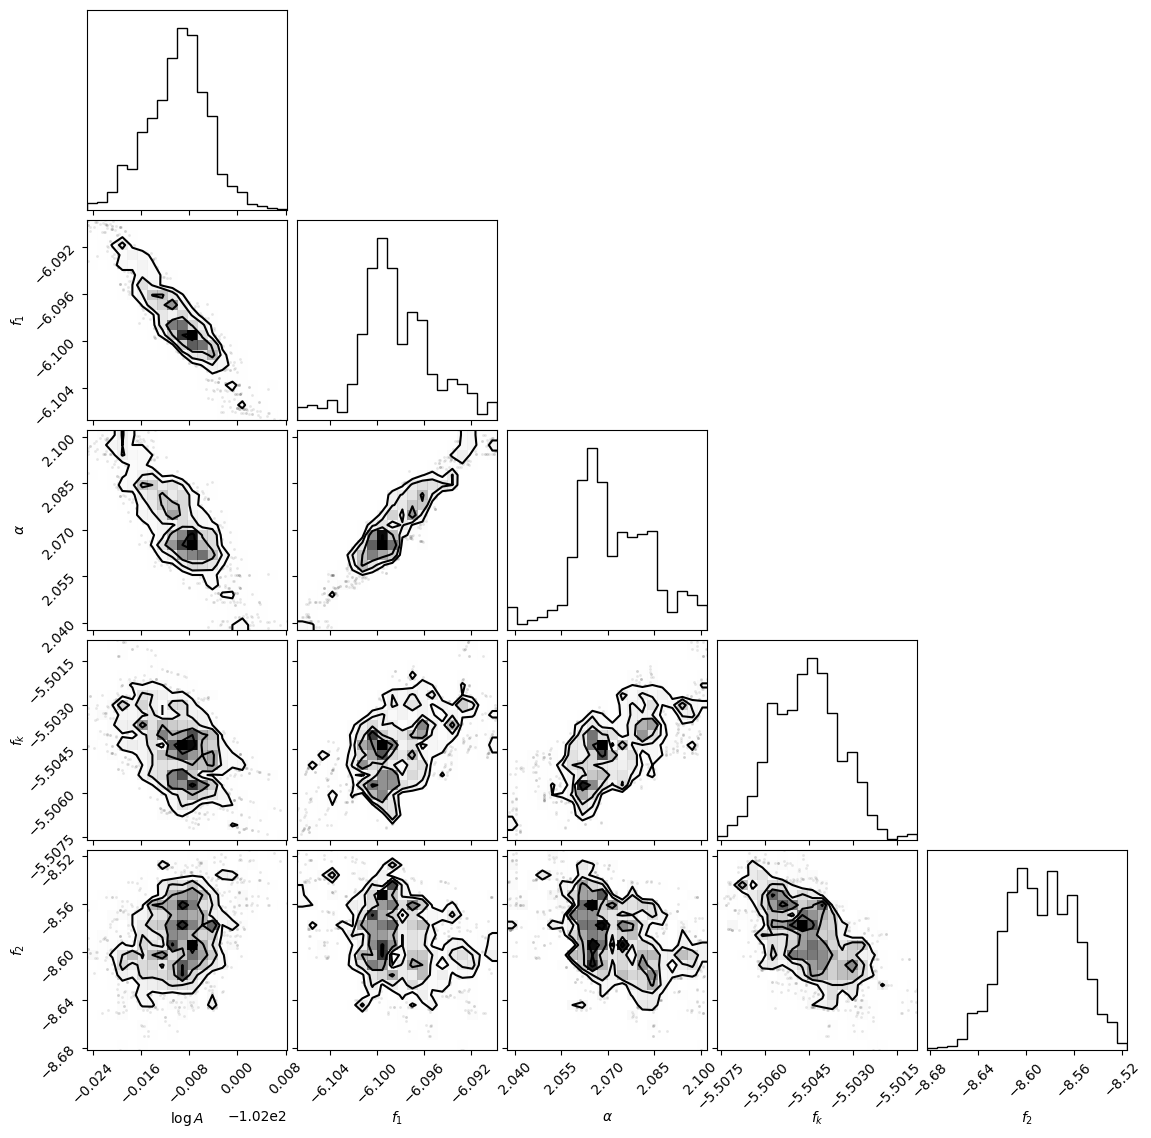

In [324]:
corner(galx_chain, labels = galx_labels)
plt.show()